# 2. H3 해상도 비교 및 공간 분석단위 선정

2024·2025년 광역버스 정류장을 H3 해상도 7·8·9로 변환하고, 셀 크기·정류장 수·노선 수를 비교한다.

※ 2025년 별도 파일인 7111번은 분석 대상에서 제외한다.

## 셀 1. 라이브러리와 분석 설정

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import h3
except ImportError as exc:
    raise ImportError("H3 패키지가 필요합니다. 터미널에서 pip install h3 실행 후 다시 실행하세요.") from exc

plt.rcParams['font.family'] = ['Malgun Gothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
BASE = Path.cwd()
if BASE.name == 'Analysis':
    BASE = BASE.parent
TRANSPORT = BASE / 'gtx_a_seoul_bus_outputs' / 'transport_card'
ROUTE_STOPS = TRANSPORT / 'route_stops'
RESOLUTIONS = [7, 8, 9]

## 셀 2. 2024·2025 정류장 자료 불러오기
7111번 별도 파일은 불러오지 않는다.

In [12]:
stops24_path = ROUTE_STOPS / 'gtx_a_route_stops_20241017.csv'
stops25_path = ROUTE_STOPS / 'gtx_a_route_stops_20251016.csv'
card24_path = TRANSPORT / 'gtx_a_transport_card_20241017_raw_with_coords_api_filled.csv'
card25_path = TRANSPORT / 'gtx_a_transport_card_20251016_raw_with_coords.csv'

stops24 = pd.read_csv(stops24_path, encoding='utf-8-sig', low_memory=False)
stops25 = pd.read_csv(stops25_path, encoding='utf-8-sig', low_memory=False)
card24 = pd.read_csv(card24_path, encoding='utf-8-sig', low_memory=False)
card25 = pd.read_csv(card25_path, encoding='utf-8-sig', low_memory=False)

# 노선-정류장 파일의 핵심 컬럼만 표준화
def standardize_route_stops(df, year):
    out = df.iloc[:, :15].copy()
    out.columns = ['route_id', 'route_no', 'route_name', 'stop_seq', 'stop_id', 'stop_name', 'sd_cd', 'sgg_cd', 'emd_cd', 'sd_name', 'sgg_name', 'emd_name', 'query_date', 'query_route_id', 'query_route_no']
    out['year'] = year
    return out[['year', 'route_no', 'route_id', 'stop_seq', 'stop_id', 'stop_name']]

route_stops = pd.concat([standardize_route_stops(stops24, 2024), standardize_route_stops(stops25, 2025)], ignore_index=True)
route_stops['stop_id'] = pd.to_numeric(route_stops['stop_id'], errors='coerce')
route_stops['route_no'] = route_stops['route_no'].astype(str)
route_stops.head()

,year,route_no,route_id,stop_seq,stop_id,stop_name
0,2024,1000,41016025,0,4111002,대화동
1,2024,1000,41016025,1,7103705,대화7단지사거리(미정차)
2,2024,1000,41016025,2,4110909,현대파크아파트.양우아파트
3,2024,1000,41016025,3,4110906,송포파출소.송포농협
4,2024,1000,41016025,4,4127137,대화역(중)


## 셀 3. 정류장 좌표 결합

In [13]:
# 최종 교통카드 파일은 좌표 관련 컬럼명이 깨져도 위치가 고정되어 있으므로 앞 13개 컬럼을 표준화한다.
def standardize_card_coords(df):
    out = df.iloc[:, :13].copy()
    out.columns = ['query_date', 'query_route_no', 'query_route_id', 'ride_stop_id', 'ride_stop_name', 'ride_stop_seq', 'ride_lat', 'ride_lon', 'goff_stop_id', 'goff_stop_name', 'goff_stop_seq', 'goff_lat', 'goff_lon']
    ride = out[['ride_stop_id', 'ride_lat', 'ride_lon']].rename(columns={'ride_stop_id': 'stop_id', 'ride_lat': 'lat', 'ride_lon': 'lon'})
    goff = out[['goff_stop_id', 'goff_lat', 'goff_lon']].rename(columns={'goff_stop_id': 'stop_id', 'goff_lat': 'lat', 'goff_lon': 'lon'})
    return pd.concat([ride, goff], ignore_index=True)

coords = pd.concat([standardize_card_coords(card24), standardize_card_coords(card25)], ignore_index=True)
coords['stop_id'] = pd.to_numeric(coords['stop_id'], errors='coerce')
coords['lat'] = pd.to_numeric(coords['lat'], errors='coerce')
coords['lon'] = pd.to_numeric(coords['lon'], errors='coerce')
coords = coords.dropna(subset=['stop_id', 'lat', 'lon'])
coords = coords.groupby('stop_id', as_index=False)[['lat', 'lon']].first()

stops = route_stops.merge(coords, on='stop_id', how='left')
stops = stops.dropna(subset=['lat', 'lon']).drop_duplicates(['year', 'route_id', 'stop_id'])
observed_card_ids = set(pd.concat([pd.to_numeric(card24.iloc[:, 3], errors='coerce'), pd.to_numeric(card24.iloc[:, 8], errors='coerce'), pd.to_numeric(card25.iloc[:, 3], errors='coerce'), pd.to_numeric(card25.iloc[:, 8], errors='coerce')]).dropna())
route_stop_ids = set(route_stops['stop_id'].dropna())
route_stops_without_card_record = route_stops['stop_id'].isin(route_stop_ids - observed_card_ids).sum()
print(f'좌표가 결합된 노선-정류장 관측치: {len(stops):,}건')
print(f'고유 정류장 수: {stops.stop_id.nunique():,}개')
print(f'노선 목록에는 있지만 조사일 승하차 기록이 없는 관측치: {route_stops_without_card_record:,}건')
print(f'조사일 승하차 기록은 있으나 좌표가 없는 정류장 ID 수: {len(observed_card_ids - set(coords.stop_id)):,}개')

좌표가 결합된 노선-정류장 관측치: 1,261건
고유 정류장 수: 317개
노선 목록에는 있지만 조사일 승하차 기록이 없는 관측치: 2,341건
조사일 승하차 기록은 있으나 좌표가 없는 정류장 ID 수: 0개


## 셀 4. H3 7·8·9 변환 및 해상도별 지표 계산

In [14]:
def latlon_to_cell(lat, lon, resolution):
    if hasattr(h3, 'latlng_to_cell'):
        return h3.latlng_to_cell(float(lat), float(lon), resolution)
    return h3.geo_to_h3(float(lat), float(lon), resolution)

for resolution in RESOLUTIONS:
    stops[f'h3_{resolution}'] = [latlon_to_cell(lat, lon, resolution) for lat, lon in zip(stops['lat'], stops['lon'])]

def h3_area(resolution):
    if hasattr(h3, 'average_hexagon_area'):
        return h3.average_hexagon_area(resolution, unit='km^2')
    return h3.hex_area(resolution, unit='km^2')

def h3_edge(resolution):
    if hasattr(h3, 'average_hexagon_edge_length'):
        return h3.average_hexagon_edge_length(resolution, unit='km')
    return h3.edge_length(resolution, unit='km')

rows = []
for resolution in RESOLUTIONS:
    cell_col = f'h3_{resolution}'
    by_cell = stops.groupby(cell_col).agg(stops=('stop_id', 'nunique'), routes=('route_no', 'nunique'))
    rows.append({
        'H3 해상도': resolution,
        '평균 셀 면적(km²)': h3_area(resolution),
        '평균 변 길이(km)': h3_edge(resolution),
        '정류장 포함 셀 수': len(by_cell),
        '셀당 정류장 수(평균)': by_cell['stops'].mean(),
        '셀당 정류장 수(중앙값)': by_cell['stops'].median(),
        '셀당 정류장 수(최대)': by_cell['stops'].max(),
        '셀당 노선 수(평균)': by_cell['routes'].mean(),
        '셀당 노선 수(중앙값)': by_cell['routes'].median(),
        '셀당 노선 수(최대)': by_cell['routes'].max(),
    })

resolution_summary = pd.DataFrame(rows).set_index('H3 해상도')
display(resolution_summary.round(3))

,평균 셀 면적(km²),평균 변 길이(km),정류장 포함 셀 수,셀당 정류장 수(평균),셀당 정류장 수(중앙값),셀당 정류장 수(최대),셀당 노선 수(평균),셀당 노선 수(중앙값),셀당 노선 수(최대)
H3 해상도,,,,,,,,,
7,5.161,1.406,94,3.372,2.5,14,3.043,2.0,12
8,0.737,0.531,200,1.585,1.0,6,2.550,2.0,10
9,0.105,0.201,288,1.101,1.0,3,2.215,2.0,10


## 셀 5. 해상도별 비교 시각화

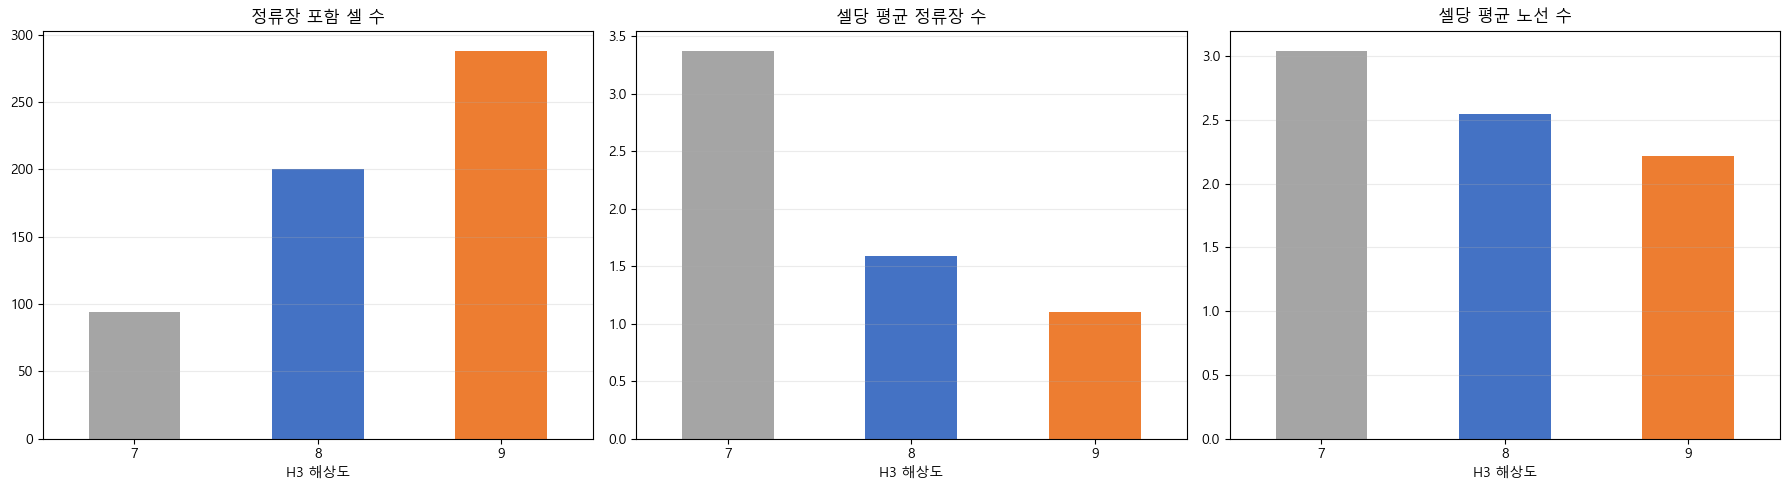

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('정류장 포함 셀 수', '정류장 포함 셀 수'), ('셀당 정류장 수(평균)', '셀당 평균 정류장 수'), ('셀당 노선 수(평균)', '셀당 평균 노선 수')]
for ax, (column, title) in zip(axes, metrics):
    resolution_summary[column].plot.bar(ax=ax, color=['#A5A5A5', '#4472C4', '#ED7D31'])
    ax.set_title(title)
    ax.set_xlabel('H3 해상도')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## 셀 6. 최종 공간 분석단위 선정

최종 분석단위는 **H3 해상도 8**로 선정한다.

- H3 7: 셀 면적이 넓어 여러 생활권과 정류장이 한 셀에 과도하게 합쳐질 수 있다.
- H3 9: 셀이 작아 정류장이 없는 셀이 많아지고, 셀당 관측 정류장·노선 수가 지나치게 세분화될 수 있다.
- H3 8: H3 7보다 공간적으로 세밀하면서 H3 9보다 안정적인 정류장·노선 집계가 가능해, 광역버스 정류장 수요를 비교하는 절충안으로 사용한다.

아래 결과표의 실제 셀 면적과 셀당 정류장·노선 수를 함께 제시하여 이 선택을 근거로 보고서에 사용한다.

In [16]:
SELECTED_RESOLUTION = 8
print(f'선정된 공간 분석단위: H3 resolution {SELECTED_RESOLUTION}')
display(resolution_summary.loc[[SELECTED_RESOLUTION]].round(3))

선정된 공간 분석단위: H3 resolution 8


,평균 셀 면적(km²),평균 변 길이(km),정류장 포함 셀 수,셀당 정류장 수(평균),셀당 정류장 수(중앙값),셀당 정류장 수(최대),셀당 노선 수(평균),셀당 노선 수(중앙값),셀당 노선 수(최대)
H3 해상도,,,,,,,,,
8,0.737,0.531,200,1.585,1.0,6,2.55,2.0,10


## 셀 7. 서울·고양·파주 시 경계 불러오기

분석 대상 행정구역: ['Goyang', 'Paju', 'Seoul']


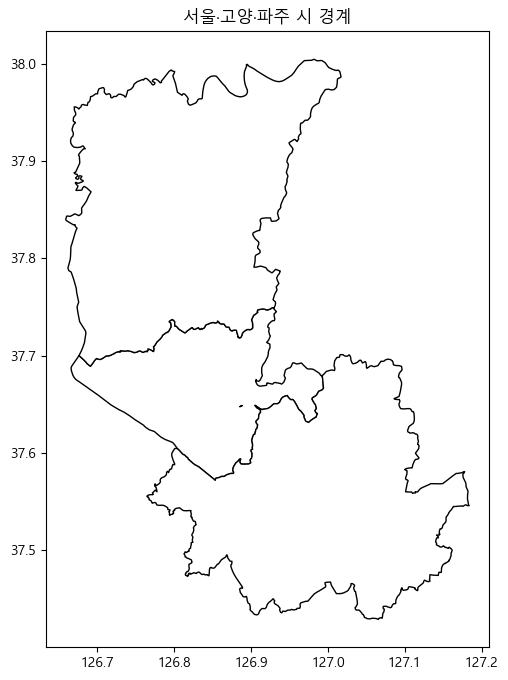

In [17]:
import geopandas as gpd
from shapely.geometry import Polygon, mapping

ADMIN_PATH = BASE / 'api_cache_gtx_a_routes' / 'HangJeongDong_ver20260701.geojson'
admin = gpd.read_file(ADMIN_PATH)
admin['sgg_code'] = admin['sgg'].astype(str).str.zfill(5)
admin['city'] = np.select([
    admin['sgg_code'].str.startswith('11'),
    admin['sgg_code'].str.startswith('4128'),
    admin['sgg_code'].str.startswith('4148'),
], ['Seoul', 'Goyang', 'Paju'], default='OUTSIDE')
admin_target = admin[admin['city'] != 'OUTSIDE'].copy()
city_boundary = admin_target.dissolve(by='city').reset_index()
target_geometry = city_boundary.geometry.union_all() if hasattr(city_boundary.geometry, 'union_all') else city_boundary.geometry.unary_union

print('분석 대상 행정구역:', city_boundary['city'].tolist())
city_boundary[['city', 'geometry']].plot(figsize=(8, 8), facecolor='white', edgecolor='black')
plt.title('서울·고양·파주 시 경계')
plt.show()

## 셀 8. H3 셀 생성 및 행정경계 안쪽 셀만 선택

H3 셀의 중심점이 서울·고양·파주 시 경계 안에 있는 경우만 지도에 표시한다.

In [18]:
SELECTED_RESOLUTION = 8
target_cells = h3.geo_to_cells(mapping(target_geometry), SELECTED_RESOLUTION) if hasattr(h3, 'geo_to_cells') else set()

def cell_to_polygon(cell):
    boundary = h3.cell_to_boundary(cell) if hasattr(h3, 'cell_to_boundary') else h3.h3_to_geo_boundary(cell)
    return Polygon([(lon, lat) for lat, lon in boundary])

cell_gdf = gpd.GeoDataFrame(
    {'h3_8': list(target_cells)},
    geometry=[cell_to_polygon(cell) for cell in target_cells],
    crs='EPSG:4326',
)
cell_gdf = cell_gdf[cell_gdf.geometry.centroid.within(target_geometry)].copy()
print(f'행정경계 안 H3 셀 수: {len(cell_gdf):,}개')

행정경계 안 H3 셀 수: 3,073개


C:\Users\금경훈\AppData\Local\Temp\ipykernel_29236\447758617.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cell_gdf = cell_gdf[cell_gdf.geometry.centroid.within(target_geometry)].copy()


## 셀 9. 정류장 수요를 H3 셀에 집계

2025년 본 데이터의 `utztn_nope` 합계를 정류장별 수요로 사용한다. 7111번 별도 파일은 포함하지 않는다. 정류장이 없는 셀은 수요 0으로 두고 흰색으로 표시한다.

In [19]:
# 승차 정류장만 사용해 연도별 승차인원을 계산한다.
def boarding_observations(df, year):
    out = df.iloc[:, :13].copy()
    out.columns = ['query_date', 'route_no', 'route_id', 'stop_id', 'stop_name', 'stop_seq', 'lat', 'lon', 'goff_stop_id', 'goff_stop_name', 'goff_stop_seq', 'goff_lat', 'goff_lon']
    out = out[['route_no', 'route_id', 'stop_id', 'stop_name', 'lat', 'lon']].copy()
    out['year'] = year
    return out

boarding_stops = pd.concat([boarding_observations(card24, 2024), boarding_observations(card25, 2025)], ignore_index=True)
boarding_stops['stop_id'] = pd.to_numeric(boarding_stops['stop_id'], errors='coerce')
boarding_stops['lat'] = pd.to_numeric(boarding_stops['lat'], errors='coerce')
boarding_stops['lon'] = pd.to_numeric(boarding_stops['lon'], errors='coerce')
boarding_stops = boarding_stops.dropna(subset=['stop_id', 'lat', 'lon']).drop_duplicates(['year', 'route_id', 'stop_id'])
boarding_stops['h3_8'] = [latlon_to_cell(lat, lon, SELECTED_RESOLUTION) for lat, lon in zip(boarding_stops['lat'], boarding_stops['lon'])]

def boarding_demand(df):
    stop_id = pd.to_numeric(df.iloc[:, 22], errors='coerce')
    users = pd.to_numeric(df.iloc[:, 27], errors='coerce').fillna(0)
    return pd.DataFrame({'stop_id': stop_id, 'boarding_users': users}).dropna(subset=['stop_id']).groupby('stop_id')['boarding_users'].sum()

demand24_boarding = boarding_demand(card24)
demand25_boarding = boarding_demand(card25)
boarding_stops['boarding_users'] = boarding_stops.apply(lambda row: (demand24_boarding if row['year'] == 2024 else demand25_boarding).get(row['stop_id'], 0), axis=1)
print('연도별 승차 정류장 수:')
display(boarding_stops.groupby('year')['stop_id'].nunique())

연도별 승차 정류장 수:


year
2024    228
2025    196
Name: stop_id, dtype: int64

## 셀 10. 정류장 수요 지도와 시 경계 표시

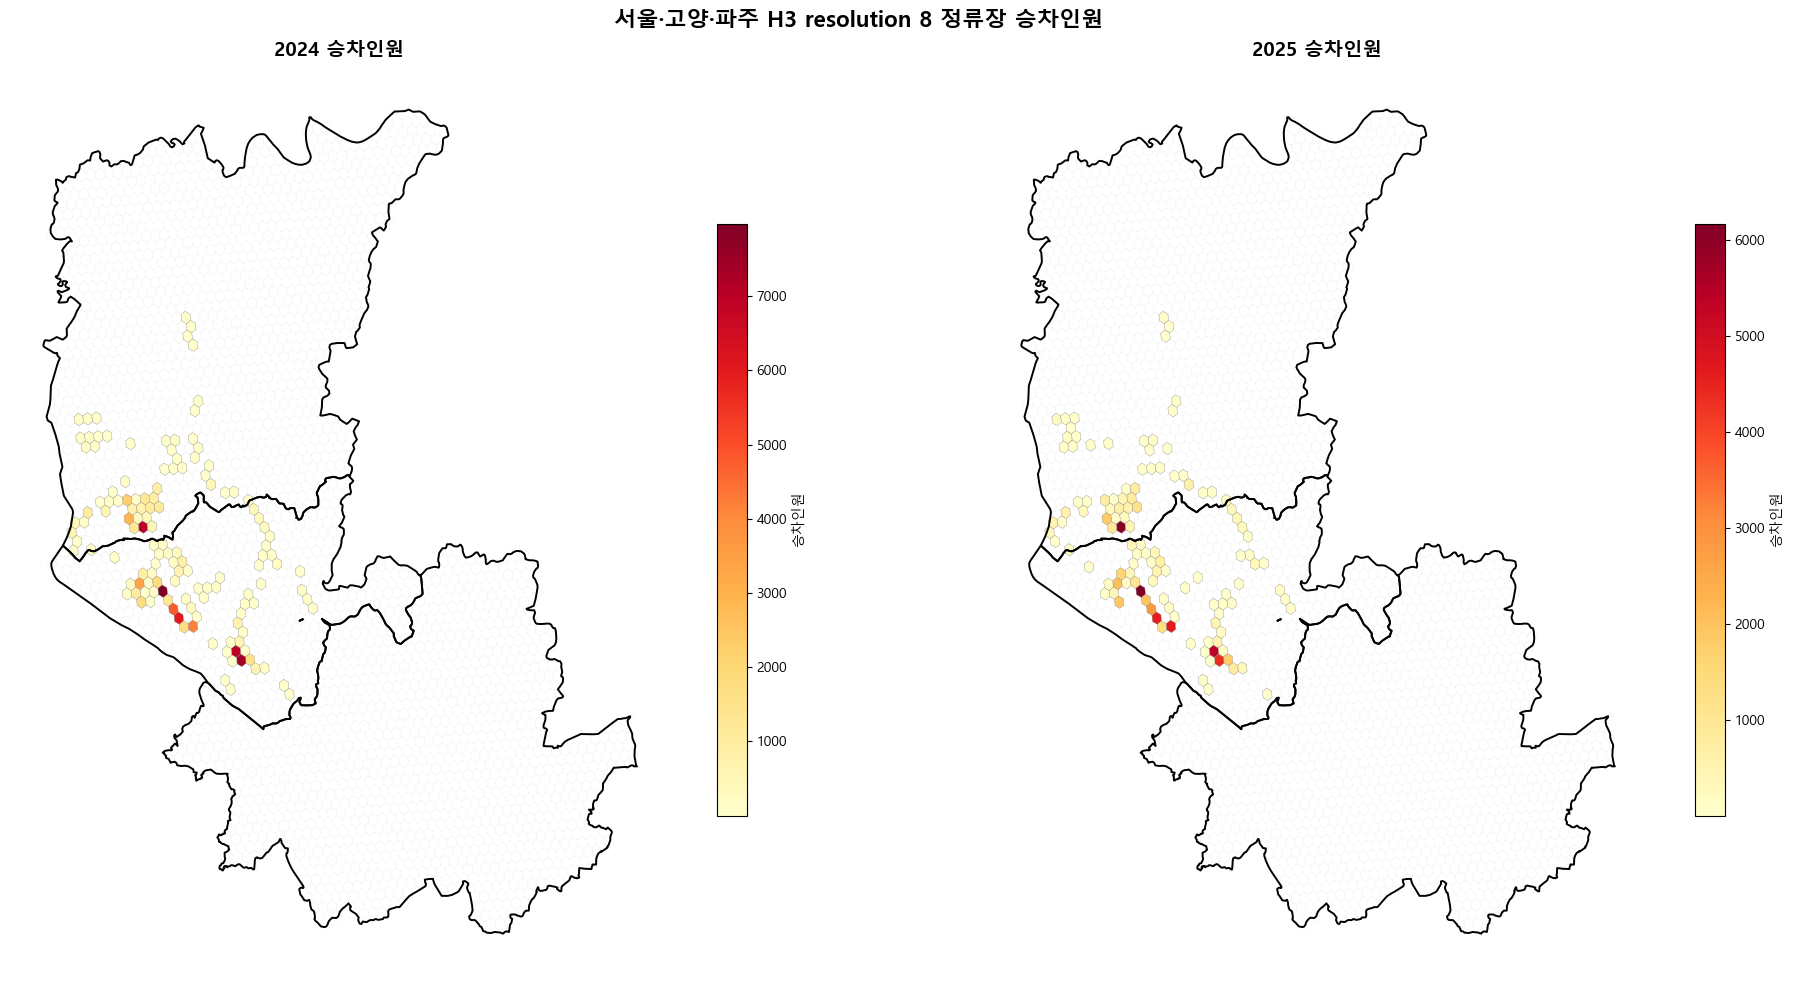

In [20]:
def plot_boarding_map(year, ax):
    year_stops = boarding_stops[boarding_stops['year'] == year]
    cell_demand = year_stops.groupby('h3_8')['boarding_users'].sum()
    plot_cells = cell_gdf.copy()
    plot_cells['boarding_users'] = plot_cells['h3_8'].map(cell_demand).fillna(0)
    plot_cells['has_boarding_stop'] = plot_cells['h3_8'].isin(year_stops['h3_8'])
    empty_cells = plot_cells[~plot_cells['has_boarding_stop']]
    active_cells = plot_cells[plot_cells['has_boarding_stop']]
    empty_cells.plot(ax=ax, facecolor='white', edgecolor='#E6E6E6', linewidth=0.15)
    if len(active_cells):
        active_cells.plot(ax=ax, column='boarding_users', cmap='YlOrRd', legend=True, edgecolor='#888888', linewidth=0.25, legend_kwds={'label': '\uC2B9\uCC28\uC778\uC6D0', 'shrink': 0.65})
    city_boundary.boundary.plot(ax=ax, color='black', linewidth=1.4)
    ax.set_title(f'{year} \uC2B9\uCC28\uC778\uC6D0', fontsize=14, fontweight='bold')
    ax.set_axis_off()

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
plot_boarding_map(2024, axes[0])
plot_boarding_map(2025, axes[1])
fig.suptitle('\uC11C\uC6B8\u00B7\uACE0\uC591\u00B7\uD30C\uC8FC H3 resolution 8 \uC815\uB958\uC7A5 \uC2B9\uCC28\uC778\uC6D0', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()